# Finding my Circadian Rhythm in Spotify Listening History

## Data Cleaning and Filtering

In [10]:
# necessary imports

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils import filter_by_hour
import scipy.signal as signal

In [3]:
fullHistory = pd.read_csv("Spotify Extended Streaming History/cleaned/cleaned-history.csv")
fullHistory['ts'] = pd.to_datetime(fullHistory['ts'])

In [4]:
hour00 = filter_by_hour(fullHistory, 0)
hour01 = filter_by_hour(fullHistory, 1)
hour02 = filter_by_hour(fullHistory, 2)
hour03 = filter_by_hour(fullHistory, 3)
hour04 = filter_by_hour(fullHistory, 4)
hour05 = filter_by_hour(fullHistory, 5)
hour06 = filter_by_hour(fullHistory, 6)
hour07 = filter_by_hour(fullHistory, 7)
hour08 = filter_by_hour(fullHistory, 8)
hour09 = filter_by_hour(fullHistory, 9)
hour10 = filter_by_hour(fullHistory, 10)
hour11 = filter_by_hour(fullHistory, 11)
hour12 = filter_by_hour(fullHistory, 12)
hour13 = filter_by_hour(fullHistory, 13)
hour14 = filter_by_hour(fullHistory, 14)
hour15 = filter_by_hour(fullHistory, 15)
hour16 = filter_by_hour(fullHistory, 16)
hour17 = filter_by_hour(fullHistory, 17)
hour18 = filter_by_hour(fullHistory, 18)
hour19 = filter_by_hour(fullHistory, 19)
hour20 = filter_by_hour(fullHistory, 20)
hour21 = filter_by_hour(fullHistory, 21)
hour22 = filter_by_hour(fullHistory, 22)
hour23 = filter_by_hour(fullHistory, 23)

In [5]:
# verifying filtering works correctly
hour00.sample(10)

,ts,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,skipped
246081,2021-02-21 00:45:15+00:00,1021,GB,I'm Sorry Boris,Wilbur Soot,Your City Gave Me Asthma,playbtn,endplay,False
307336,2021-11-15 00:14:31+00:00,259444,GB,Andromeda,Weyes Blood,Titanic Rising,appload,trackdone,False
96069,2023-08-13 00:30:16+00:00,12027,GB,They'll Only Miss You When You Leave,Carissa's Wierd,Songs About Leaving,appload,fwdbtn,True
22531,2022-02-03 00:21:55+00:00,140626,GB,Say Yes,Elliott Smith,Either/Or,trackdone,trackdone,False
238869,2021-01-17 00:36:50+00:00,46490,GB,We Didn't Start the Fire,Billy Joel,Storm Front,trackdone,endplay,False
302233,2021-10-21 00:24:50+00:00,193030,GB,Snap Out Of It,Arctic Monkeys,AM,trackdone,trackdone,False
62673,2022-11-14 00:04:14+00:00,76115,GB,They'll Only Miss You When You Leave,Carissa's Wierd,Songs About Leaving,appload,fwdbtn,True
281719,2021-07-23 00:09:23+00:00,191130,GB,A Bottle of Rum,Xiu Xiu,OH NO,trackdone,trackdone,False
113683,2024-01-16 00:31:31+00:00,406103,GB,いきのこり●ぼくら,Ichiko Aoba,0,trackdone,trackdone,False
67310,2022-12-17 00:50:35+00:00,184516,GB,Pink + White,Frank Ocean,Blonde,trackdone,trackdone,False


## Finding The Underlying Schedule

In [6]:
hours = [hour00, hour01, hour02, hour03, hour04, hour05, hour06, hour07, hour08, hour09, hour10, hour11, hour12, hour13, hour14, hour15, hour16, hour17, hour18, hour19, hour20, hour21, hour22, hour23]

In [7]:
allTime = fullHistory['ms_played'].sum()
hourSplits = []
for hour in hours:
    hourTotal = hour['ms_played'].sum()
    ratio = round((hourTotal/allTime)*100, 2) 
    hourSplits.append(float(ratio))
    print(f"Hour {hour['ts'].dt.hour.iloc[0]}: {ratio}% of total listening time")

Hour 0: 4.25% of total listening time
Hour 1: 2.03% of total listening time
Hour 2: 1.09% of total listening time
Hour 3: 0.66% of total listening time
Hour 4: 0.48% of total listening time
Hour 5: 0.39% of total listening time
Hour 6: 1.04% of total listening time
Hour 7: 2.96% of total listening time
Hour 8: 3.94% of total listening time
Hour 9: 4.17% of total listening time
Hour 10: 4.92% of total listening time
Hour 11: 4.79% of total listening time
Hour 12: 4.28% of total listening time
Hour 13: 4.2% of total listening time
Hour 14: 5.28% of total listening time
Hour 15: 5.99% of total listening time
Hour 16: 6.85% of total listening time
Hour 17: 6.11% of total listening time
Hour 18: 5.31% of total listening time
Hour 19: 5.54% of total listening time
Hour 20: 5.89% of total listening time
Hour 21: 6.41% of total listening time
Hour 22: 7.05% of total listening time
Hour 23: 6.38% of total listening time


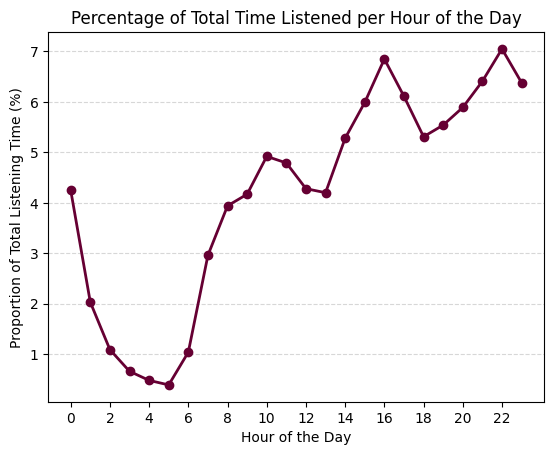

In [8]:
plt.plot(hourSplits, marker='o', ls='-', c='#660033', linewidth=2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(0,24,2))
plt.title('Percentage of Total Time Listened per Hour of the Day')
plt.ylabel('Proportion of Total Listening Time (%)')
plt.xlabel('Hour of the Day')
plt.show()

Based on the raw numbers above, I can see a clear period of peak listening from 2pm to 11pm, with a non-negligible amount of tracks being listened to from 7am-1pm and in the midnight hour. However, I want to further analyse the timestamps and find out the distribution of my listening.

In [11]:
signal.find_peaks(hourSplits, height=0.5, distance=1)

(array([10, 16, 22]), {'peak_heights': array([4.92, 6.85, 7.05])})

The peaks in my data tell me that my primary listening sessions occur in the late morning, late afternoon and late evening. My instinctual guess is that this is because I will listen to music after breakfast whilst working, when I've come home from college/high school (I have had the account since year 6), and before I go to sleep. I'm going to perform a KDE on the data to try and verify the quickly calculated numbers above.

## Finding my Average Mood in Specific Hours

## Anomaly Detection

## Measuring Diversity in Listening at Certain Hours